Đang load model...
Đang nhận diện...

image 1/1 /Users/ducquynguyen/Desktop/tài liệu đại học(landscape+long edge)/kì 2 năm 3/data project2/train1xemay/images/xemay973_jpg.rf.caa4a9b28b02d8edd5f0812a71cf73c5.jpg: 640x640 1 license_plate, 149.9ms
Speed: 1.1ms preprocess, 149.9ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


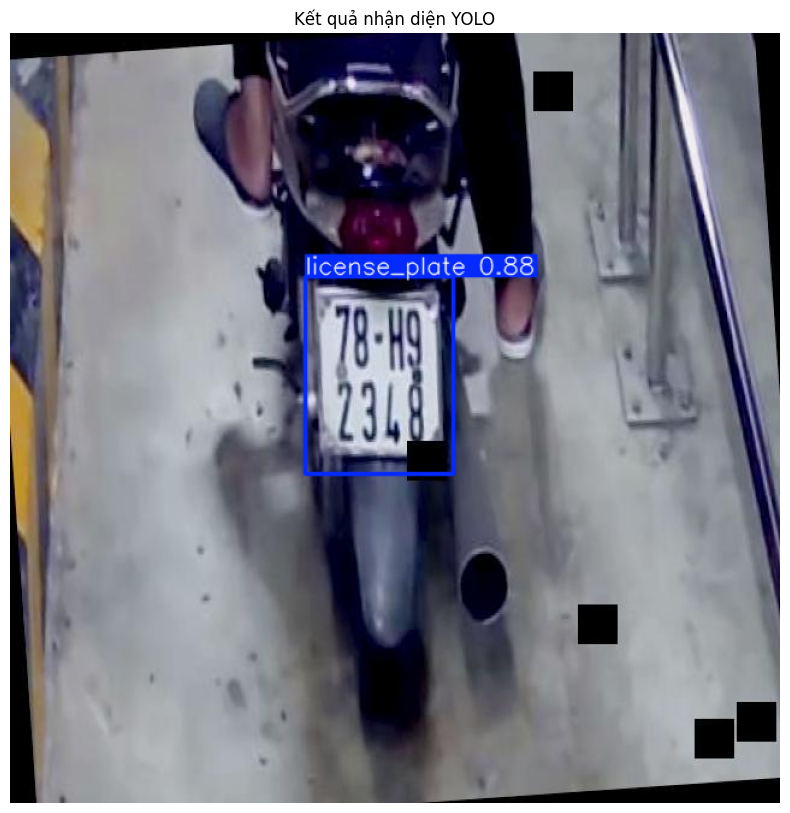

------------------------------
Tìm thấy 1 biển số:
Biển số 1: Tọa độ [x1: 245.4, y1: 202.8, x2: 368.1, y2: 366.3] | Độ tin cậy: 87.59%


In [8]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Khai báo đường dẫn (Nhớ thay đổi image_path thành đường dẫn ảnh thật của bạn)
model_path = '/Users/ducquynguyen/Desktop/tài liệu đại học(landscape+long edge)/kì 2 năm 3/project 2/train_8m-2/weights/best.pt'
image_path = '/Users/ducquynguyen/Desktop/tài liệu đại học(landscape+long edge)/kì 2 năm 3/data project2/train1xemay/images/xemay973_jpg.rf.caa4a9b28b02d8edd5f0812a71cf73c5.jpg'
# 2. Load model
print("Đang load model...")
model = YOLO(model_path)

# 3. Chạy dự đoán (Inference)
print("Đang nhận diện...")
results = model(image_path)

# 4. Trích xuất kết quả (lấy phần tử đầu tiên vì mình chỉ truyền 1 ảnh)
result = results[0]

# YOLOv8 có sẵn hàm plot() tự động vẽ bounding box và độ tin cậy lên ảnh
img_with_boxes = result.plot()

# OpenCV đọc ảnh hệ màu BGR, trong khi matplotlib hiển thị hệ RGB nên cần chuyển đổi
img_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)

# 5. Hiển thị ảnh kèm khung nhận diện
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Kết quả nhận diện YOLO")
plt.show()

# 6. (Tùy chọn) In chi tiết tọa độ ra để bạn đối chiếu xem App có bị lấy sai không
print("-" * 30)
if len(result.boxes) == 0:
    print("Không tìm thấy biển số nào trong ảnh!")
else:
    print(f"Tìm thấy {len(result.boxes)} biển số:")
    for i, box in enumerate(result.boxes):
        coords = box.xyxy[0].tolist() # Tọa độ [x1, y1, x2, y2]
        conf = box.conf[0].item()     # Độ tin cậy
        print(f"Biển số {i+1}: Tọa độ [x1: {coords[0]:.1f}, y1: {coords[1]:.1f}, x2: {coords[2]:.1f}, y2: {coords[3]:.1f}] | Độ tin cậy: {conf*100:.2f}%")

/var/folders/68/k7gdvy9j4qs0964qr5hv4l2h0000gn/T/ipykernel_51711/1247491337.py:6: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ducquynguyen/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/ducquynguyen/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


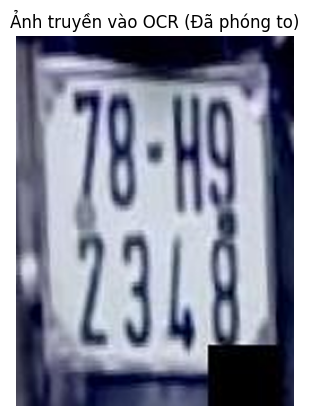

------------------------------
Dòng 1: 78-H9 | Độ tin cậy: 0.9753
Dòng 2: 2348 | Độ tin cậy: 0.9935


In [12]:
from paddleocr import PaddleOCR
import matplotlib.pyplot as plt
import cv2

# Khởi tạo PaddleOCR: Ép buộc TẮT tính năng tự động xoay ảnh tài liệu
ocr = PaddleOCR(
    lang='en', 
    use_angle_cls=False,
    use_doc_orientation_classify=False,
    use_doc_unwarping=False
)

# 1. Trích xuất ảnh biển số từ kết quả YOLO
box = result.boxes.xyxy[0].cpu().numpy().astype(int)
x1, y1, x2, y2 = box
plate_crop = result.orig_img[y1:y2, x1:x2]

# 2. Phóng to ảnh (Upscale) gấp 2 lần bằng thuật toán CUBIC để làm rõ nét chữ
plate_crop_resized = cv2.resize(plate_crop, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# Hiển thị ảnh sau khi phóng to
plt.imshow(cv2.cvtColor(plate_crop_resized, cv2.COLOR_BGR2RGB))
plt.title("Ảnh truyền vào OCR (Đã phóng to)")
plt.axis('off')
plt.show()

# 3. Chạy OCR (Dùng .predict thay cho .ocr để hết bị Warning)
try:
    ocr_results = ocr.predict(plate_crop_resized)
except Exception as e:
    # Fallback lại hàm cũ nếu predict bị lỗi tham số ở bản của bạn
    ocr_results = ocr.ocr(plate_crop_resized)

# 4. Xử lý kết quả
print("-" * 30)
found_text = False

if ocr_results and isinstance(ocr_results, list) and len(ocr_results) > 0:
    first_result = ocr_results[0]
    
    # Kiểm tra xem nó có phải là dictionary (như kết quả thô bạn vừa gửi không)
    if isinstance(first_result, dict):
        # Trích xuất text từ rec_texts nếu có
        rec_texts = first_result.get('rec_texts', [])
        rec_scores = first_result.get('rec_scores', [])
        
        if rec_texts:
            for i, text in enumerate(rec_texts):
                score = rec_scores[i] if i < len(rec_scores) else 0.0
                print(f"Dòng {i+1}: {text} | Độ tin cậy: {score:.4f}")
                found_text = True
                
    # Fallback cho format list cũ của PaddleOCR
    elif isinstance(first_result, list): 
        for i, line in enumerate(first_result):
            if isinstance(line, list) and len(line) == 2 and isinstance(line[1], tuple):
                text = line[1][0]
                conf = line[1][1]
                print(f"Dòng {i+1}: {text} | Độ tin cậy: {conf:.4f}")
                found_text = True

if not found_text:
    print("Không tìm thấy văn bản nào. Cấu trúc raw hiện tại:")
    print(ocr_results)